# Gradient descent

Gradient descent is the basic parameter-updating procedure behind many models in machine learning. The procedure is simple: evaluate an objective, compute its gradient with respect to the parameters, and move in the opposite direction. The important part is understanding what the step size changes. A small step can make progress slowly, a suitable step approaches the minimum, and a large step can overshoot or diverge.

This notebook studies those cases on an objective whose minimum is known exactly. That makes the experiment a diagnostic for the update rule rather than a search for an unknown answer. The same quantities—parameters, objective value, gradient, and learning rate—reappear when the objective is a regression loss or a neural-network loss.


## Objective and update

The objective is

```text
J(theta) = (theta - 3)^2
```

It is a parabola with its unique minimum at `theta = 3`, where `J(theta) = 0`. The derivative is

```text
dJ/dtheta = 2(theta - 3)
```

At a point to the left of `3`, the derivative is negative and the update increases `theta`. At a point to the right, the derivative is positive and the update decreases `theta`. Gradient descent therefore uses

```text
theta_next = theta - eta * dJ/dtheta
```

where `eta` is the learning rate. Here the update can be written as `theta_next - 3 = (1 - 2 eta)(theta - 3)`, so the whole behaviour is determined by the multiplier `1 - 2 eta`.


## The exact behaviour of the learning rate

Let `e = theta - 3` be the current error. After one update,

```text
e_next = (1 - 2 eta)e
```

For `0 < eta < 0.5`, the magnitude of the error decreases without changing sign when `eta <= 0.5` is small enough for a monotone approach. For `0.5 < eta < 1`, the sign alternates while the magnitude still shrinks, which appears as controlled overshooting. At `eta = 1`, the error keeps the same magnitude and the method does not converge. For `eta > 1`, the error grows.

The code below records both the objective value and the parameter at every update. Keeping the parameter trace matters: two runs can have similar loss values while arriving from different sides of the minimum.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


def objective(theta):
    return (theta - 3.0) ** 2


def grad(theta):
    return 2.0 * (theta - 3.0)


def descend(theta, eta, steps=30):
    path = [float(theta)]
    for _ in range(steps):
        theta = theta - eta * grad(theta)
        path.append(float(theta))
    return np.array(path)

rates = [0.1, 0.49, 0.6, 1.0, 1.1]
for eta in rates:
    path = descend(0.0, eta)
    print(f'eta={eta:>4}: final theta={path[-1]: .5f}, final loss={objective(path[-1]):.3e}')

Matplotlib is building the font cache; this may take a moment.


eta= 0.1: final theta= 2.99629, final loss=1.379e-05
eta=0.49: final theta= 3.00000, final loss=0.000e+00
eta= 0.6: final theta= 3.00000, final loss=0.000e+00
eta= 1.0: final theta= 0.00000, final loss=9.000e+00
eta= 1.1: final theta=-709.12894, final loss=5.071e+05


## Comparing learning rates

The static plots show the same runs in two coordinate systems. The left panel places the parameter on the objective curve, so it shows where each update is made. The right panel shows the scalar loss on a logarithmic scale, which makes both early and late progress visible. A straight-looking segment on the log plot represents approximately geometric convergence, not a constant decrease in the original loss.


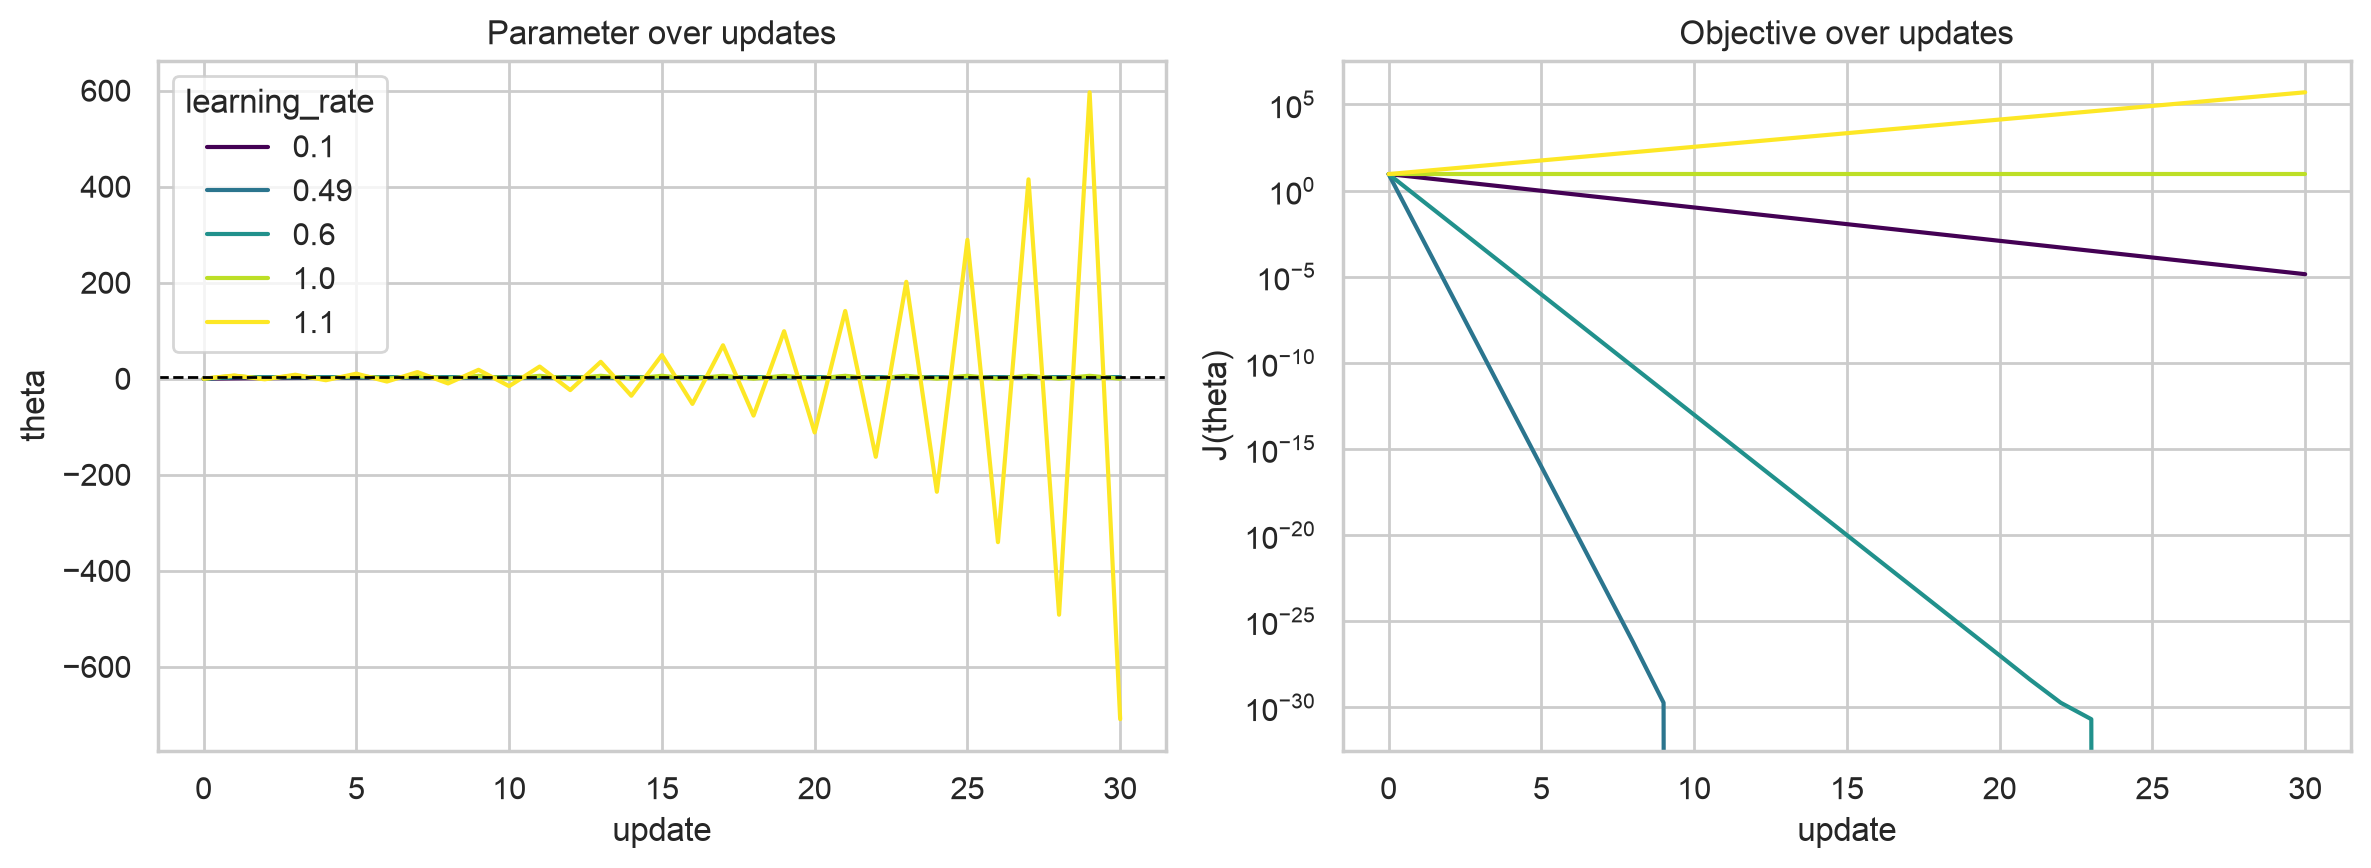

In [2]:
import pandas as pd
import seaborn as sns

records = []
for eta in rates:
    path = descend(0.0, eta)
    records.extend({"update": i, "theta": theta, "objective": objective(theta), "learning_rate": eta}
                   for i, theta in enumerate(path))
trace = pd.DataFrame(records)

sns.set_theme(style="whitegrid", context="notebook")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.lineplot(data=trace, x="update", y="theta", hue="learning_rate", palette="viridis", ax=axes[0])
axes[0].axhline(3, color="black", linestyle="--", linewidth=1, label="minimum")
axes[0].set(title="Parameter over updates", ylabel="theta")
sns.lineplot(data=trace, x="update", y="objective", hue="learning_rate", palette="viridis", legend=False, ax=axes[1])
axes[1].set(yscale="log", title="Objective over updates", ylabel="J(theta)")
fig.tight_layout()
plt.show()


## Reading the traces

The useful comparison is between the parameter path and the loss path. A run can reduce the loss while alternating around the optimum; that is not a failure if the oscillations shrink. Conversely, a run that initially reduces the loss can still be unstable if its learning rate eventually makes the error grow. In a real model the objective is rarely one-dimensional, but the same diagnosis applies along directions of high and low curvature.


## Implementation

The implementation keeps the update rule explicit so that the recorded history can be inspected directly. There is no optimizer object in this first example: `descend` evaluates the derivative and applies the scalar update. The later notebooks use the same loop idea with vector-valued parameters and then move to PyTorch optimizers.


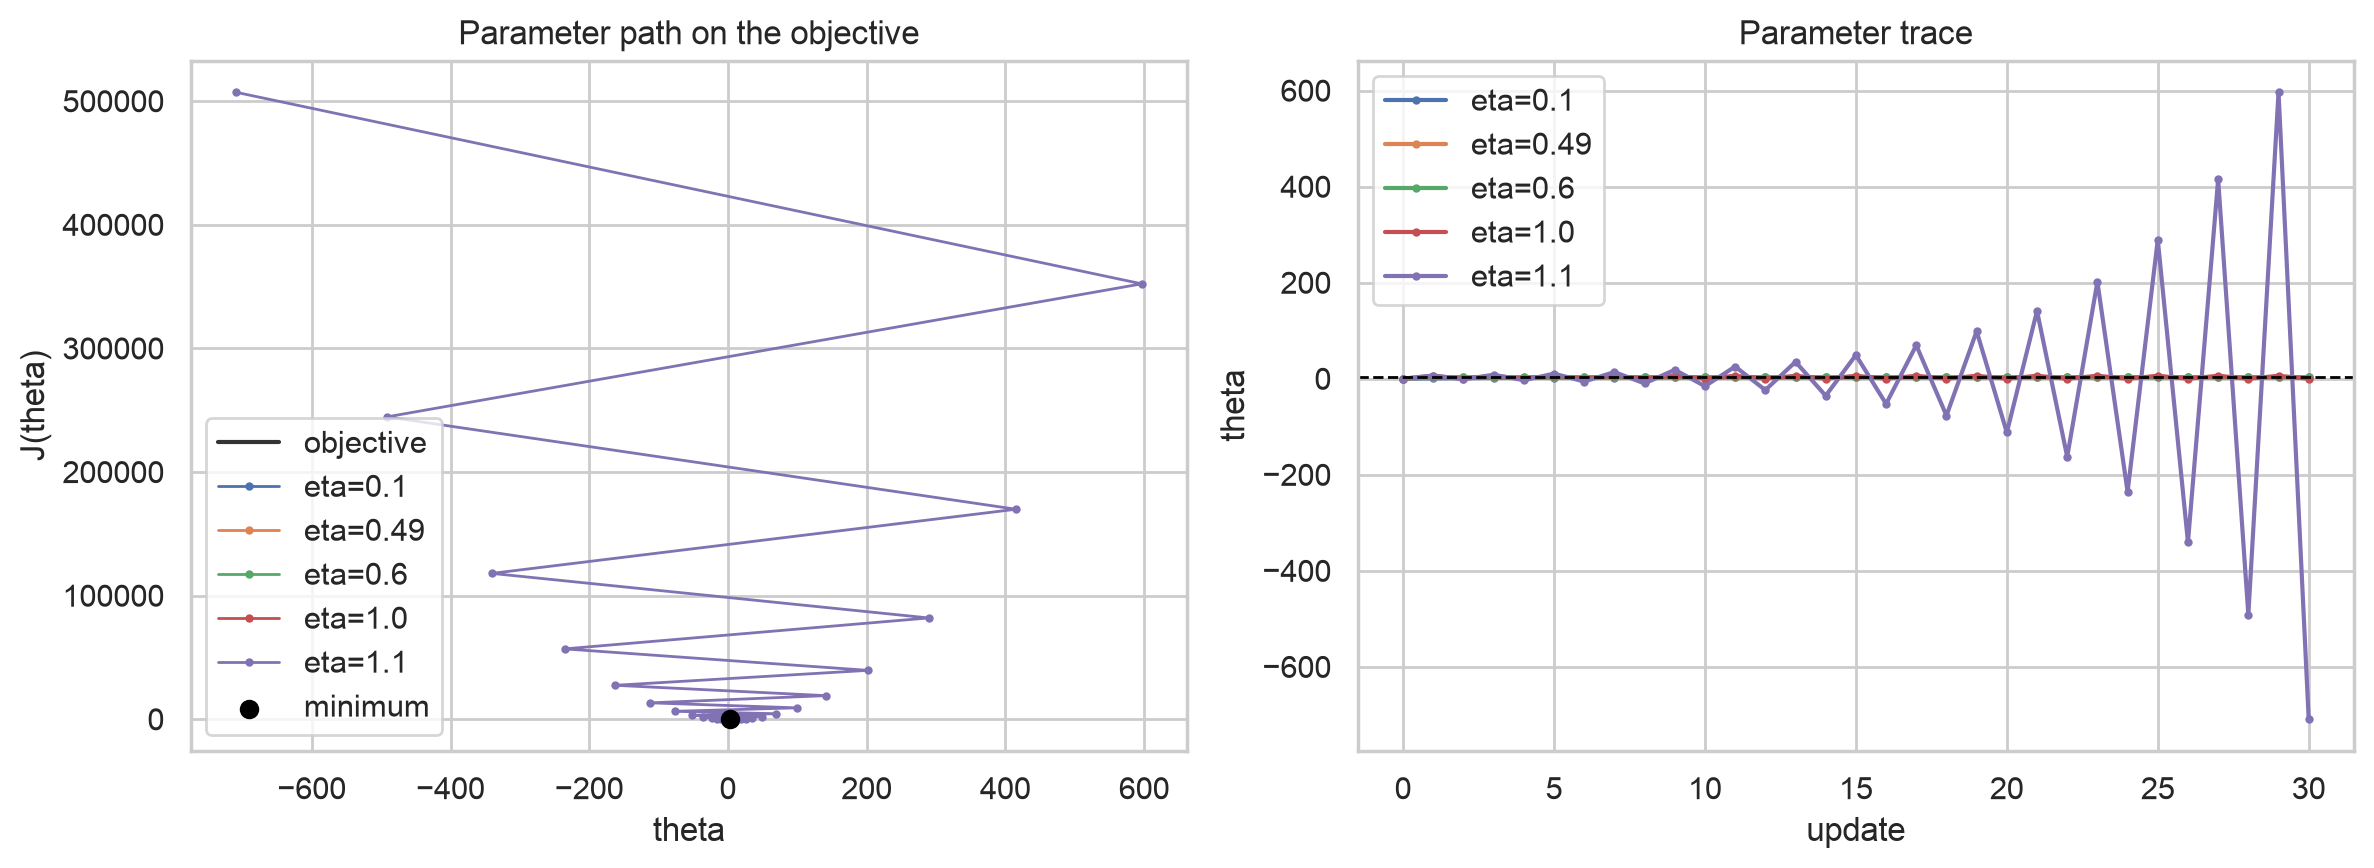

In [3]:
theta_grid = np.linspace(-1, 7, 400)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(theta_grid, objective(theta_grid), color="0.2", label="objective")
for eta in rates:
    path = descend(0.0, eta)
    axes[0].plot(path, objective(path), marker="o", markersize=2, linewidth=1, label=f"eta={eta}")
axes[0].scatter([3], [0], color="black", zorder=3, label="minimum")
axes[0].set(xlabel="theta", ylabel="J(theta)", title="Parameter path on the objective")
axes[0].legend()

for eta in rates:
    path = descend(0.0, eta)
    axes[1].plot(path, marker="o", markersize=2, label=f"eta={eta}")
axes[1].axhline(3, color="black", linestyle="--", linewidth=1)
axes[1].set(xlabel="update", ylabel="theta", title="Parameter trace")
axes[1].legend()
fig.tight_layout()
plt.show()


## Connection to model training

In regression, `theta` is replaced by a vector of weights and biases, and the derivative becomes a gradient with one component per parameter. The update has the same form. The main additional difficulties are that the gradient is estimated from data, the objective may be non-convex, and different directions can have very different curvature. This one-dimensional example isolates the role of the learning rate before those effects are introduced.
